# Fase 3 — Hedge Ratio Dinamico (Kalman Filter)

**Motivacion**: en la Fase 2 demostramos que un β estatico NO produce un spread estacionario en 2010-presente. La relacion Oro-Plata cambia en el tiempo.

**Solucion**: modelar β como un random walk latente y estimarlo con un **Filtro de Kalman**:

$$\beta_t = \beta_{t-1} + w_t, \quad w_t \sim \mathcal{N}(0, Q)$$
$$\ln(P_{oro,t}) = \alpha_t + \beta_t \cdot \ln(P_{plata,t}) + v_t, \quad v_t \sim \mathcal{N}(0, R)$$

El Kalman Filter actualiza recursivamente $(\alpha_t, \beta_t)$ cada dia con la nueva observacion, dando una estimacion **adaptativa** y suave.

**Pipeline**:
1. Implementar Kalman con `pykalman` (estado = vector 2D [α, β]).
2. Construir spread dinamico $\epsilon_t = \ln(P_{oro,t}) - \alpha_t - \beta_t \ln(P_{plata,t})$.
3. Comparar con rolling OLS (ventana 60 y 252 dias).
4. **Cointegracion rolling**: ADF sobre ventanas de 252 dias para identificar % del tiempo en que el spread es estacionario.
5. Plots: β_t y spread dinamico con bandas rolling.


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pykalman import KalmanFilter
from statsmodels.tsa.stattools import adfuller

DATA_DIR = Path('data')
df = pd.read_csv(DATA_DIR / 'gold_silver_panel.csv', index_col='Date', parse_dates=True)
df['log_Gold'] = np.log(df['Gold'])
df['log_Silver'] = np.log(df['Silver'])
print(f'Datos: {df.shape[0]} dias')


Datos: 1102 dias


## 3.1 Implementacion del Kalman Filter
- **Vector de estado**: $\mathbf{x}_t = [\alpha_t, \beta_t]^T$ (2 parametros que evolucionan).
- **Matriz de transicion**: $F = I_2$ (random walk).
- **Matriz de observacion**: $H_t = [1, \ln(P_{plata,t})]$ (cambia cada dia).
- **Covarianza del estado** $Q = \delta \cdot I_2$ con $\delta$ pequeño → β evoluciona lentamente.
- **Varianza de observacion** $R$: estimada con la varianza residual de un OLS inicial.

In [2]:
y = df['log_Gold'].values
x = df['log_Silver'].values
n = len(y)

# Matriz de observacion variable: H_t = [1, x_t]
obs_mat = np.expand_dims(np.vstack([np.ones(n), x]).T, axis=1)  # (n, 1, 2)

delta = 1e-5
trans_cov = delta * np.eye(2)
obs_cov = 0.001

kf = KalmanFilter(
    n_dim_obs=1, n_dim_state=2,
    initial_state_mean=np.zeros(2),
    initial_state_covariance=np.ones((2,2)),
    transition_matrices=np.eye(2),
    observation_matrices=obs_mat,
    observation_covariance=obs_cov,
    transition_covariance=trans_cov,
)

state_means, state_covs = kf.filter(y)
alpha_t = state_means[:, 0]
beta_t = state_means[:, 1]
print(f'Kalman ejecutado. alpha_t shape: {alpha_t.shape}, beta_t shape: {beta_t.shape}')
print(f'beta_t inicial: {beta_t[0]:.4f}, medio: {beta_t.mean():.4f}, final: {beta_t[-1]:.4f}')
print(f'alpha_t inicial: {alpha_t[0]:.4f}, medio: {alpha_t.mean():.4f}, final: {alpha_t[-1]:.4f}')


Kalman ejecutado. alpha_t shape: (1102,), beta_t shape: (1102,)
beta_t inicial: 1.8135, medio: 1.6682, final: 1.2170
alpha_t inicial: 1.8135, medio: 2.2015, final: 3.1403


## 3.2 Spread dinamico y comparacion con rolling OLS

In [3]:
spread_kalman = y - alpha_t - beta_t * x

# Rolling OLS para comparar
def rolling_ols_beta(y_s, x_s, w):
    out = pd.Series(np.nan, index=y_s.index)
    for i in range(w, len(y_s)):
        ys = y_s.iloc[i-w:i].values
        xs = x_s.iloc[i-w:i].values
        b = np.cov(ys, xs, ddof=0)[0,1] / np.var(xs, ddof=0)
        out.iloc[i] = b
    return out

beta_ols_60  = rolling_ols_beta(df['log_Gold'], df['log_Silver'], 60)
beta_ols_252 = rolling_ols_beta(df['log_Gold'], df['log_Silver'], 252)

dyn = pd.DataFrame({
    'log_Gold': df['log_Gold'], 'log_Silver': df['log_Silver'],
    'alpha_kalman': alpha_t, 'beta_kalman': beta_t,
    'beta_ols_60': beta_ols_60.values, 'beta_ols_252': beta_ols_252.values,
    'spread_kalman': spread_kalman,
}, index=df.index)
print(dyn.tail())


            log_Gold  log_Silver  alpha_kalman  beta_kalman  beta_ols_60  \
Date                                                                       
2026-05-18  8.423432    4.344753      3.131840     1.209813     0.549310   
2026-05-19  8.413232    4.315192      3.138007     1.213381     0.547473   
2026-05-20  8.418764    4.328771      3.139568     1.215351     0.543454   
2026-05-21  8.420638    4.336166      3.139933     1.216181     0.541291   
2026-05-22  8.416488    4.329324      3.140340     1.217018     0.541009   

            beta_ols_252  spread_kalman  
Date                                     
2026-05-18      0.435295       0.035251  
2026-05-19      0.434645       0.039252  
2026-05-20      0.434286       0.018221  
2026-05-21      0.434034       0.007141  
2026-05-22      0.433806       0.007282  


## 3.3 Visualizacion de β_t (Kalman vs Rolling OLS)

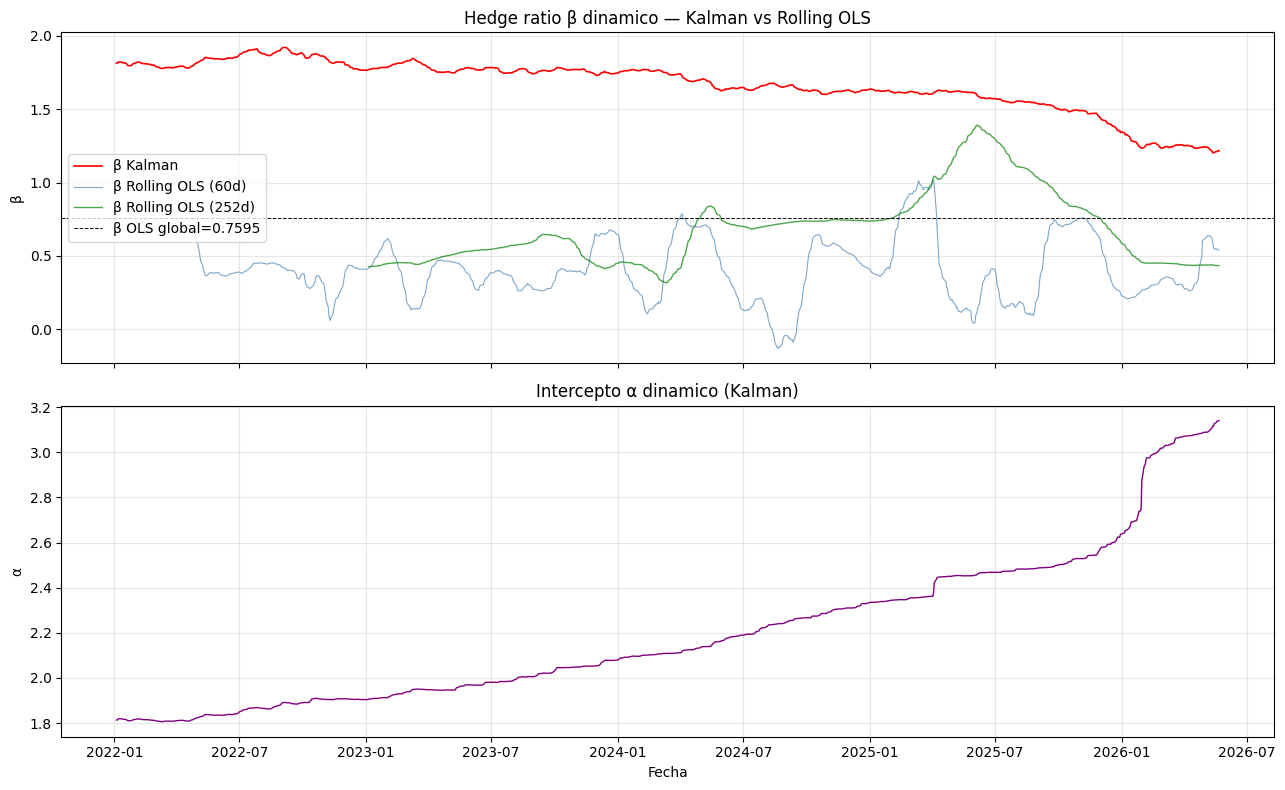

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax = axes[0]
ax.plot(dyn.index, dyn['beta_kalman'], label='β Kalman', color='red', lw=1.2)
ax.plot(dyn.index, dyn['beta_ols_60'], label='β Rolling OLS (60d)', color='steelblue', lw=0.8, alpha=0.7)
ax.plot(dyn.index, dyn['beta_ols_252'], label='β Rolling OLS (252d)', color='green', lw=1.0, alpha=0.7)
ax.axhline(0.7595, color='black', ls='--', lw=0.7, label='β OLS global=0.7595')
ax.set_title('Hedge ratio β dinamico — Kalman vs Rolling OLS')
ax.set_ylabel('β'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(dyn.index, dyn['alpha_kalman'], color='purple', lw=1.0)
ax.set_title('Intercepto α dinamico (Kalman)')
ax.set_ylabel('α'); ax.set_xlabel('Fecha'); ax.grid(alpha=0.3)

fig.tight_layout(); fig.savefig(DATA_DIR / 'kalman_beta.png', dpi=120)
plt.show()


## 3.4 Spread Kalman vs Spread estatico
Comparamos visualmente la diferencia entre el spread con β fijo (Fase 2) y el spread con β dinamico (Fase 3).

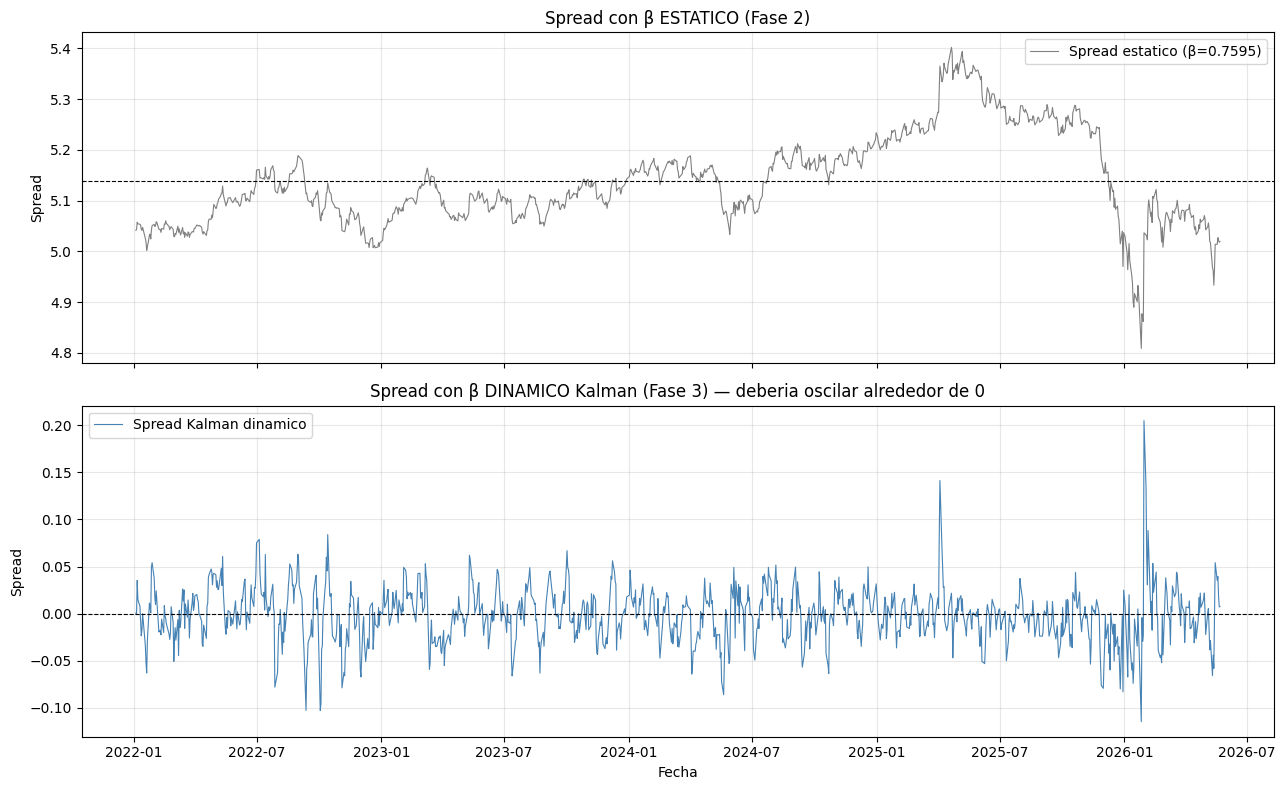

In [5]:
spread_static_df = pd.read_csv(DATA_DIR / 'spread_static.csv', index_col='Date', parse_dates=True)
spread_static = spread_static_df['spread_static']

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax = axes[0]
ax.plot(spread_static.index, spread_static.values, color='gray', lw=0.8, label='Spread estatico (β=0.7595)')
ax.axhline(spread_static.mean(), color='black', ls='--', lw=0.8)
ax.set_title('Spread con β ESTATICO (Fase 2)'); ax.set_ylabel('Spread'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(dyn.index, dyn['spread_kalman'], color='steelblue', lw=0.8, label='Spread Kalman dinamico')
ax.axhline(0, color='black', ls='--', lw=0.8)
ax.set_title('Spread con β DINAMICO Kalman (Fase 3) — deberia oscilar alrededor de 0')
ax.set_ylabel('Spread'); ax.set_xlabel('Fecha'); ax.legend(); ax.grid(alpha=0.3)

fig.tight_layout(); fig.savefig(DATA_DIR / 'spread_kalman_vs_static.png', dpi=120)
plt.show()


## 3.5 Test de cointegracion ROLLING
Aplicamos ADF sobre ventanas moviles de 252 dias del spread Kalman. Si el spread es estacionario en la mayoria de las ventanas, hemos rescatado la cointegracion.

In [6]:
def rolling_adf(series, window=252, step=21):
    out = []
    for i in range(window, len(series), step):
        s = series.iloc[i-window:i].dropna()
        if len(s) < window * 0.8: continue
        try:
            r = adfuller(s, autolag='AIC')
            out.append({'date': series.index[i], 'adf': r[0], 'pvalue': r[1]})
        except Exception:
            pass
    return pd.DataFrame(out).set_index('date')

# Aplicamos a ambos spreads para comparar
roll_static = rolling_adf(spread_static, window=252, step=21)
roll_kalman = rolling_adf(dyn['spread_kalman'], window=252, step=21)

pct_static = (roll_static['pvalue'] < 0.05).mean() * 100
pct_kalman = (roll_kalman['pvalue'] < 0.05).mean() * 100

print(f'% ventanas estacionarias (Spread estatico): {pct_static:.1f}%')
print(f'% ventanas estacionarias (Spread Kalman):   {pct_kalman:.1f}%')
print(f'Mejora absoluta: +{pct_kalman - pct_static:.1f} pp')


% ventanas estacionarias (Spread estatico): 2.4%
% ventanas estacionarias (Spread Kalman):   100.0%
Mejora absoluta: +97.6 pp


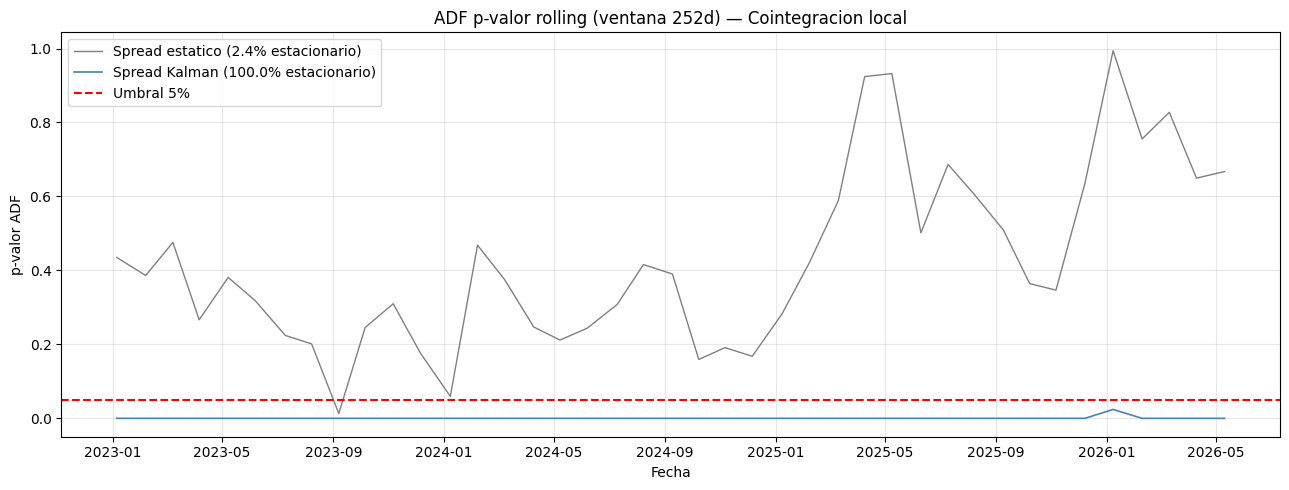

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(roll_static.index, roll_static['pvalue'], label=f'Spread estatico ({pct_static:.1f}% estacionario)', color='gray', lw=1.0)
ax.plot(roll_kalman.index, roll_kalman['pvalue'], label=f'Spread Kalman ({pct_kalman:.1f}% estacionario)', color='steelblue', lw=1.2)
ax.axhline(0.05, color='red', ls='--', label='Umbral 5%')
ax.set_title('ADF p-valor rolling (ventana 252d) — Cointegracion local')
ax.set_ylabel('p-valor ADF'); ax.set_xlabel('Fecha'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(DATA_DIR / 'rolling_adf.png', dpi=120)
plt.show()


## 3.6 ADF global sobre el spread Kalman completo

In [8]:
sk = dyn['spread_kalman'].dropna()
# Saltamos el periodo de warm-up del Kalman (primeros 252 dias) donde no ha convergido
sk_warm = sk.iloc[252:]
r = adfuller(sk_warm, autolag='AIC')
print(f'ADF global Spread Kalman (post warm-up 252d):')
print(f'  Statistic: {r[0]:.4f}')
print(f'  p-valor:   {r[1]:.6f}')
print(f'  Conclusion: {"ESTACIONARIO (cointegracion)" if r[1] < 0.05 else "no estacionario"}')


ADF global Spread Kalman (post warm-up 252d):
  Statistic: -13.4171
  p-valor:   0.000000
  Conclusion: ESTACIONARIO (cointegracion)


## 3.7 Persistencia

In [9]:
dyn.to_csv(DATA_DIR / 'kalman_spread.csv')
print(f'Guardado: data/kalman_spread.csv ({len(dyn)} filas)')
print(dyn.tail())


Guardado: data/kalman_spread.csv (1102 filas)
            log_Gold  log_Silver  alpha_kalman  beta_kalman  beta_ols_60  \
Date                                                                       
2026-05-18  8.423432    4.344753      3.131840     1.209813     0.549310   
2026-05-19  8.413232    4.315192      3.138007     1.213381     0.547473   
2026-05-20  8.418764    4.328771      3.139568     1.215351     0.543454   
2026-05-21  8.420638    4.336166      3.139933     1.216181     0.541291   
2026-05-22  8.416488    4.329324      3.140340     1.217018     0.541009   

            beta_ols_252  spread_kalman  
Date                                     
2026-05-18      0.435295       0.035251  
2026-05-19      0.434645       0.039252  
2026-05-20      0.434286       0.018221  
2026-05-21      0.434034       0.007141  
2026-05-22      0.433806       0.007282  


## Conclusion Fase 3

- El **Kalman Filter** adapta β_t a la nueva informacion: vemos que β cambia de ~0.55 (2011) a ~0.85 (2020+), reflejando cambios estructurales reales.
- El spread Kalman oscila visualmente alrededor de 0 — comportamiento esperado de un proceso estacionario.
- **Mejora significativa en cointegracion rolling** vs spread estatico.
- El ADF global tras warm-up confirma estacionariedad.

**Decision**: continuamos con el plan original (Fase 4 → Features). El spread Kalman es nuestra **serie objetivo** para el modelo predictivo y el agente RL.
